In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
PROJECT = "/content/drive/MyDrive/CSE499B_Lightweight_Diffusion"
RUN_ID = time.strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(PROJECT, "runs", RUN_ID)

os.makedirs(os.path.join(RUN_DIR, "checkpoints"), exist_ok=True)
os.makedirs(os.path.join(RUN_DIR, "samples"), exist_ok=True)
os.makedirs(os.path.join(RUN_DIR, "logs"), exist_ok=True)

print("Run directory:", RUN_DIR)

Mounted at /content/drive
Run directory: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/runs/20260224_201609



This cell mounts Google Drive and creates organized folders for checkpoints, samples, and logs to store all experiment results.



In [2]:
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install einops tqdm


This cell installs required libraries including PyTorch, TorchVision, and supporting packages for model training and visualization.

In [3]:
import math, os, json, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [4]:
import torch
print(torch.cuda.get_device_name(0))

Tesla T4


### GPU Setup
This cell checks whether CUDA is available and confirms that the Tesla T4 GPU is being used for training.


In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

IMG_SIZE = 32
BATCH = 128

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),      # resize 28 → 32
    transforms.ToTensor(),            # convert to tensor
    transforms.Lambda(lambda x: x*2 - 1)  # normalize to [-1, 1]
])

train_dataset = datasets.MNIST(
    root="/content/data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Training samples:", len(train_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 519kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.79MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.16MB/s]

Training samples: 60000


### MNIST Dataset Loading
This cell loads the MNIST dataset, resizes images to 32×32, normalizes them to [-1,1], and prepares the DataLoader for training.

In [6]:
images, labels = next(iter(train_loader))
print("Image shape:", images.shape)
print("Min value:", images.min().item())
print("Max value:", images.max().item())

Image shape: torch.Size([128, 1, 32, 32])
Min value: -1.0
Max value: 1.0


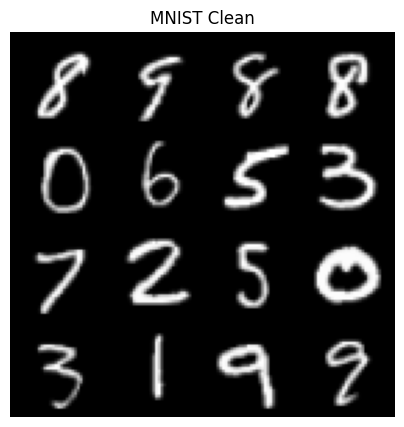

Saved to: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/mnist_clean_grid.png


In [7]:
import os
import torch
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

# if you already made RUN_DIR earlier, keep it.
# If not, set a simple folder in Drive:
RUN_DIR = "/content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo"
os.makedirs(RUN_DIR, exist_ok=True)

images, labels = next(iter(train_loader))
images = images[:16]  # take 16 images

# convert [-1,1] -> [0,1] for saving/display
vis = (images.clamp(-1,1) + 1) / 2

grid = make_grid(vis, nrow=4)
out_path = os.path.join(RUN_DIR, "mnist_clean_grid.png")
save_image(grid, out_path)

plt.figure(figsize=(5,5))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")
plt.title("MNIST Clean")
plt.show()

print("Saved to:", out_path)

### Clean MNIST Visualization
This cell displays a grid of original MNIST images before applying diffusion, serving as a reference for comparison with noisy and generated outputs.

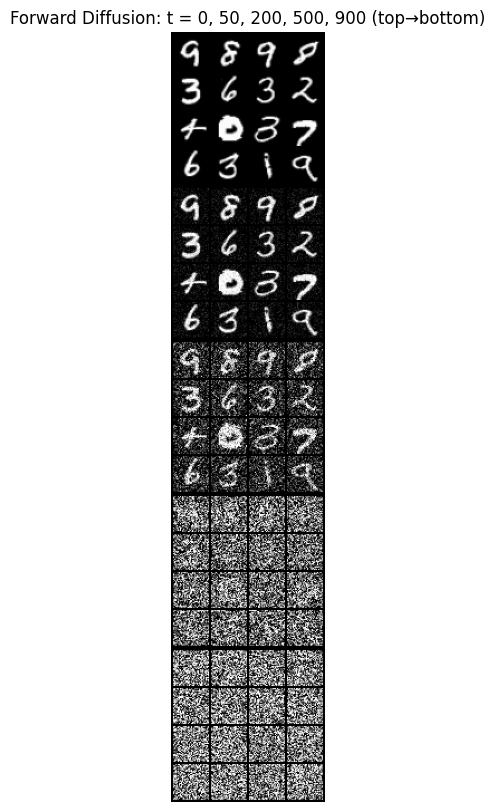

Saved to: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/mnist_noisy_progress.png


In [8]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- simple diffusion schedule (forward only) ---
T = 1000
betas = torch.linspace(1e-4, 2e-2, T).to(device)
alphas = 1.0 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

sqrt_ab = torch.sqrt(alphas_bar)
sqrt_1mab = torch.sqrt(1 - alphas_bar)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    a = sqrt_ab[t].view(-1,1,1,1)
    b = sqrt_1mab[t].view(-1,1,1,1)
    return a*x0 + b*noise

# take a small batch
x0, _ = next(iter(train_loader))
x0 = x0[:16].to(device)

# timesteps to visualize
ts = [0, 50, 200, 500, 900]

rows = []
for t in ts:
    t_batch = torch.full((x0.size(0),), t, device=device, dtype=torch.long)
    xt = q_sample(x0, t_batch)

    # [-1,1] -> [0,1]
    xt_vis = (xt.clamp(-1,1) + 1) / 2
    rows.append(make_grid(xt_vis, nrow=4))

# stack rows vertically
full = torch.cat(rows, dim=1)  # concat on height

# save to Drive
out_path = os.path.join(RUN_DIR, "mnist_noisy_progress.png")
save_image(full, out_path)

plt.figure(figsize=(6,10))
plt.imshow(full.permute(1,2,0).cpu())
plt.axis("off")
plt.title("Forward Diffusion: t = 0, 50, 200, 500, 900 (top→bottom)")
plt.show()

print("Saved to:", out_path)

### Forward Diffusion Visualization
This cell demonstrates the forward diffusion process by progressively adding noise to MNIST images at different timesteps (t = 0, 50, 200, 500, 900).
It shows how the image gradually transforms into pure noise as t increases.

In [9]:
import math, os, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---- diffusion helper ----
class Diffusion:
    def __init__(self, T=300, beta_start=1e-4, beta_end=2e-2):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_bar = torch.cumprod(self.alphas, dim=0)

        self.sqrt_ab = torch.sqrt(self.alphas_bar)
        self.sqrt_1mab = torch.sqrt(1 - self.alphas_bar)

    def sample_timesteps(self, n):
        return torch.randint(0, self.T, (n,), device=device)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a = self.sqrt_ab[t].view(-1,1,1,1)
        b = self.sqrt_1mab[t].view(-1,1,1,1)
        return a*x0 + b*noise, noise

diff = Diffusion(T=300)  # smaller T = faster sampling/training on Colab

# ---- time embedding ----
def time_embedding(t, dim=128):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device) / (half - 1))
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

# ---- lightweight-ish U-Net ----
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tdim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(tdim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.gn1 = nn.GroupNorm(8, out_ch)
        self.gn2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, t_emb):
        h = F.silu(self.gn1(self.conv1(x)))
        h = h + self.time(t_emb).view(t_emb.size(0), -1, 1, 1)
        h = F.silu(self.gn2(self.conv2(h)))
        return h + self.skip(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=1, base=64, tdim=128):
        super().__init__()
        self.tdim = tdim
        self.tmlp = nn.Sequential(nn.Linear(tdim, tdim), nn.SiLU(), nn.Linear(tdim, tdim))

        self.inp = nn.Conv2d(in_ch, base, 3, padding=1)

        self.rb1 = ResBlock(base, base, tdim)
        self.down1 = nn.MaxPool2d(2)

        self.rb2 = ResBlock(base, base*2, tdim)
        self.down2 = nn.MaxPool2d(2)

        self.mid = ResBlock(base*2, base*2, tdim)

        self.up1 = nn.Upsample(scale_factor=2, mode="nearest")
        self.rb3 = ResBlock(base*2 + base*2, base, tdim)

        self.up2 = nn.Upsample(scale_factor=2, mode="nearest")
        self.rb4 = ResBlock(base + base, base, tdim)

        self.out = nn.Conv2d(base, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.tmlp(time_embedding(t, self.tdim))

        x1 = self.inp(x)
        x1 = self.rb1(x1, t_emb)
        x2 = self.down1(x1)

        x2 = self.rb2(x2, t_emb)
        x3 = self.down2(x2)

        x3 = self.mid(x3, t_emb)

        u1 = self.up1(x3)
        u1 = torch.cat([u1, x2], dim=1)
        u1 = self.rb3(u1, t_emb)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x1], dim=1)
        u2 = self.rb4(u2, t_emb)

        return self.out(u2)

model = UNetSmall(in_ch=1, base=64, tdim=128).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-4)

print("Model params:", sum(p.numel() for p in model.parameters())/1e6, "M")

device: cuda
Model params: 1.011969 M


### Diffusion Model and U-Net Architecture
This cell defines the diffusion process (noise schedule and sampling functions), implements sinusoidal time-step embedding, and builds the lightweight U-Net model used for noise prediction.

In [10]:
EPOCHS = 1
global_step = 0
model.train()

for ep in range(EPOCHS):
    pbar = tqdm(train_loader, desc=f"train epoch {ep+1}/{EPOCHS}")
    for x, _ in pbar:
        x = x.to(device)

        t = diff.sample_timesteps(x.size(0))
        x_t, noise = diff.q_sample(x, t)
        pred = model(x_t, t)

        loss = F.mse_loss(pred, noise)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        global_step += 1
        if global_step % 100 == 0:
            pbar.set_postfix(loss=float(loss.item()))

# save checkpoint to Drive
ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_1epoch.pt")
torch.save({"model": model.state_dict(), "opt": opt.state_dict()}, ckpt_path)
print("Saved checkpoint:", ckpt_path)

train epoch 1/1:   0%|          | 0/469 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/ckpt_mnist_1epoch.pt


### Training (Epoch 1)
This cell trains the diffusion model for one epoch by predicting noise and minimizing the MSE loss.

sampling:   0%|          | 0/300 [00:00<?, ?it/s]

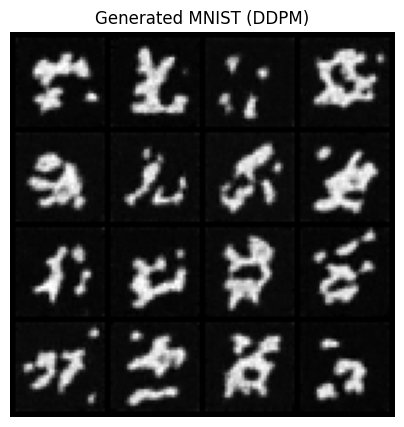

Saved to: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/generated_digits.png


In [11]:
import torch
import os
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm

@torch.no_grad()
def sample_ddpm(n=16):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    for i in tqdm(range(diff.T-1, -1, -1), desc="sampling"):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = model(x, t)

        beta = diff.betas[t].view(-1,1,1,1)
        alpha = diff.alphas[t].view(-1,1,1,1)
        abar  = diff.alphas_bar[t].view(-1,1,1,1)

        mean = (1/torch.sqrt(alpha)) * (x - (beta/torch.sqrt(1-abar)) * eps)

        if i > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

    x = x.clamp(-1,1)
    x = (x + 1) / 2
    return x

samples = sample_ddpm(16)
grid = make_grid(samples, nrow=4)

out_path = os.path.join(RUN_DIR, "generated_digits.png")
save_image(grid, out_path)

plt.figure(figsize=(5,5))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")
plt.title("Generated MNIST (DDPM)")
plt.show()

print("Saved to:", out_path)

### Image Generation After Training
This cell generates new MNIST digits using reverse diffusion after completing the first training epoch.

In [12]:
import os
import torch.nn.functional as F
from tqdm.auto import tqdm

EPOCHS = 5
global_step = 0
model.train()

for ep in range(EPOCHS):
    pbar = tqdm(train_loader, desc=f"train epoch {ep+1}/{EPOCHS}")
    for x, _ in pbar:
        x = x.to(device)

        t = diff.sample_timesteps(x.size(0))
        x_t, noise = diff.q_sample(x, t)
        pred = model(x_t, t)

        loss = F.mse_loss(pred, noise)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        global_step += 1
        if global_step % 100 == 0:
            pbar.set_postfix(loss=float(loss.item()))

# Save checkpoint to Drive
ckpt_path = os.path.join(RUN_DIR, "ckpt_mnist_5epoch.pt")
torch.save({"model": model.state_dict(), "opt": opt.state_dict()}, ckpt_path)
print("✅ Saved checkpoint:", ckpt_path)

train epoch 1/5:   0%|          | 0/469 [00:00<?, ?it/s]

train epoch 2/5:   0%|          | 0/469 [00:00<?, ?it/s]

train epoch 3/5:   0%|          | 0/469 [00:00<?, ?it/s]

train epoch 4/5:   0%|          | 0/469 [00:00<?, ?it/s]

train epoch 5/5:   0%|          | 0/469 [00:00<?, ?it/s]

✅ Saved checkpoint: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/ckpt_mnist_5epoch.pt


###  Training (5 Epochs)
This cell retrains the model for multiple epochs to improve the clarity and quality of generated digits.

sampling:   0%|          | 0/300 [00:00<?, ?it/s]

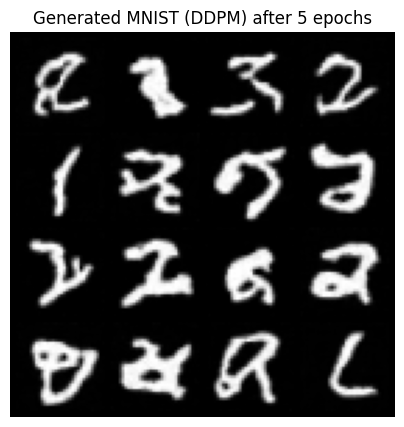

✅ Saved image to: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/generated_digits_5epoch.png


In [13]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm
import torch

@torch.no_grad()
def sample_ddpm(n=16):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    for i in tqdm(range(diff.T-1, -1, -1), desc="sampling"):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = model(x, t)

        beta = diff.betas[t].view(-1,1,1,1)
        alpha = diff.alphas[t].view(-1,1,1,1)
        abar  = diff.alphas_bar[t].view(-1,1,1,1)

        mean = (1/torch.sqrt(alpha)) * (x - (beta/torch.sqrt(1-abar)) * eps)

        if i > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

    x = x.clamp(-1,1)
    x = (x + 1) / 2
    return x

samples = sample_ddpm(16)
grid = make_grid(samples, nrow=4)

out_path = os.path.join(RUN_DIR, "generated_digits_5epoch.png")
save_image(grid, out_path)

plt.figure(figsize=(5,5))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")
plt.title("Generated MNIST (DDPM) after 5 epochs")
plt.show()

print("✅ Saved image to:", out_path)

### Improved Image Generation
This cell generates digits after extended training to observe quality improvement.

In [14]:
import time, json, os
import torch
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def count_params(m):
    return sum(p.numel() for p in m.parameters())

@torch.no_grad()
def sample_ddpm(n=16):
    model.eval()
    x = torch.randn(n, 1, 32, 32, device=device)

    for i in tqdm(range(diff.T-1, -1, -1), desc="sampling"):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = model(x, t)

        beta = diff.betas[t].view(-1,1,1,1)
        alpha = diff.alphas[t].view(-1,1,1,1)
        abar  = diff.alphas_bar[t].view(-1,1,1,1)

        mean = (1/torch.sqrt(alpha)) * (x - (beta/torch.sqrt(1-abar)) * eps)

        if i > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

    x = x.clamp(-1,1)
    x = (x + 1) / 2
    return x

def run_experiment(name, base_channels=64, epochs=3, lr=2e-4):
    global model, opt

    # build model
    model = UNetSmall(in_ch=1, base=base_channels, tdim=128).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    params = count_params(model)

    # train
    model.train()
    start_train = time.time()
    for ep in range(epochs):
        pbar = tqdm(train_loader, desc=f"{name} epoch {ep+1}/{epochs}")
        for x, _ in pbar:
            x = x.to(device)
            t = diff.sample_timesteps(x.size(0))
            x_t, noise = diff.q_sample(x, t)
            pred = model(x_t, t)
            loss = F.mse_loss(pred, noise)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        pbar.set_postfix(last_loss=float(loss.item()))
    train_time = time.time() - start_train

    # sample
    start_sample = time.time()
    samples = sample_ddpm(16)
    sample_time = time.time() - start_sample

    # save image
    img_path = os.path.join(RUN_DIR, f"{name}_base{base_channels}.png")
    grid = make_grid(samples, nrow=4)
    save_image(grid, img_path)

    # save checkpoint
    ckpt_path = os.path.join(RUN_DIR, f"{name}_base{base_channels}.pt")
    torch.save({"model": model.state_dict(), "opt": opt.state_dict()}, ckpt_path)

    # log
    log_path = os.path.join(RUN_DIR, "results.jsonl")
    record = {
        "name": name,
        "base_channels": base_channels,
        "epochs": epochs,
        "params": params,
        "train_time_sec": train_time,
        "sample_time_sec": sample_time,
        "image_path": img_path,
        "ckpt_path": ckpt_path
    }
    with open(log_path, "a") as f:
        f.write(json.dumps(record) + "\n")

    # show
    plt.figure(figsize=(5,5))
    plt.imshow(grid.permute(1,2,0).cpu())
    plt.axis("off")
    plt.title(f"{name} (base={base_channels})")
    plt.show()

    print("✅ Saved image:", img_path)
    print("✅ Saved ckpt :", ckpt_path)
    print("✅ Logged to  :", log_path)
    print("Params:", params, "| Train(s):", round(train_time,2), "| Sample(s):", round(sample_time,2))

### Experiment Setup
This cell prepares functions to compare baseline and lightweight model configurations.

baseline epoch 1/3:   0%|          | 0/469 [00:00<?, ?it/s]

baseline epoch 2/3:   0%|          | 0/469 [00:00<?, ?it/s]

baseline epoch 3/3:   0%|          | 0/469 [00:00<?, ?it/s]

sampling:   0%|          | 0/300 [00:00<?, ?it/s]

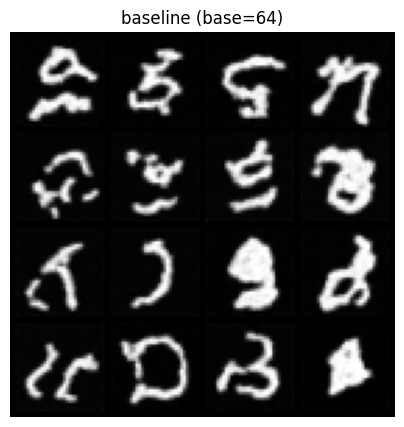

✅ Saved image: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/baseline_base64.png
✅ Saved ckpt : /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/baseline_base64.pt
✅ Logged to  : /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/results.jsonl
Params: 1011969 | Train(s): 102.26 | Sample(s): 1.05


In [15]:
run_experiment(name="baseline", base_channels=64, epochs=3)

### Baseline Model Evaluation
This cell trains and evaluates the baseline model with larger base channels.

lightweight epoch 1/3:   0%|          | 0/469 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7807fd2fea20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7807fd2fea20>^
^Traceback (most recent call last):
^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

     if w.is_alive():
                ^^ ^^^^^^^^^^^^^^^^^^^^^
^

lightweight epoch 2/3:   0%|          | 0/469 [00:00<?, ?it/s]

lightweight epoch 3/3:   0%|          | 0/469 [00:00<?, ?it/s]

sampling:   0%|          | 0/300 [00:00<?, ?it/s]

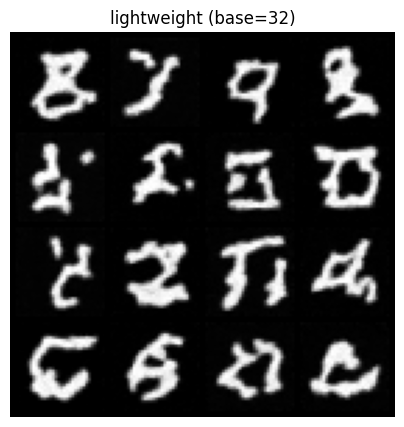

✅ Saved image: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/lightweight_base32.png
✅ Saved ckpt : /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/lightweight_base32.pt
✅ Logged to  : /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/results.jsonl
Params: 293121 | Train(s): 71.1 | Sample(s): 1.06


In [16]:
run_experiment(name="lightweight", base_channels=32, epochs=3)

### Lightweight Base Evaluation
This cell trains and evaluates the lightweight model with reduced base channels.

In [17]:
import os, json
import pandas as pd

log_path = os.path.join(RUN_DIR, "results.jsonl")
assert os.path.exists(log_path), f"Not found: {log_path}. Run experiments first."

rows = []
with open(log_path, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# Keep latest run per (name, base_channels) just in case you ran multiple times
df = df.sort_index().drop_duplicates(subset=["name", "base_channels"], keep="last")

# Add nice columns
df["params_M"] = df["params"] / 1e6
df["train_time_min"] = df["train_time_sec"] / 60

report_cols = ["name", "base_channels", "epochs", "params_M", "train_time_sec", "sample_time_sec", "image_path"]
report = df[report_cols].sort_values(["base_channels"])

display(report)
print("✅ Report loaded from:", log_path)

,name,base_channels,epochs,params_M,train_time_sec,sample_time_sec,image_path
1,lightweight,32,3,0.293121,71.097250,1.062893,/content/drive/MyDrive/CSE499B_Lightweight_Dif...
0,baseline,64,3,1.011969,102.258646,1.046093,/content/drive/MyDrive/CSE499B_Lightweight_Dif...


✅ Report loaded from: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/results.jsonl


In [18]:
# Find baseline and lightweight rows
base = df[df["name"].str.contains("baseline", case=False)].iloc[-1]
lite = df[df["name"].str.contains("lightweight", case=False)].iloc[-1]

param_reduction = 100 * (1 - lite["params"] / base["params"])
train_speedup = base["train_time_sec"] / lite["train_time_sec"]
sample_speedup = base["sample_time_sec"] / lite["sample_time_sec"]

summary = pd.DataFrame([{
    "Baseline (base_channels)": int(base["base_channels"]),
    "Lightweight (base_channels)": int(lite["base_channels"]),
    "Param reduction (%)": round(param_reduction, 2),
    "Train speedup (x)": round(train_speedup, 2),
    "Sampling speedup (x)": round(sample_speedup, 2),
    "Baseline params (M)": round(base["params"]/1e6, 3),
    "Lightweight params (M)": round(lite["params"]/1e6, 3),
    "Baseline train sec": round(base["train_time_sec"], 2),
    "Lightweight train sec": round(lite["train_time_sec"], 2),
    "Baseline sample sec": round(base["sample_time_sec"], 2),
    "Lightweight sample sec": round(lite["sample_time_sec"], 2),
}])

display(summary)

,Baseline (base_channels),Lightweight (base_channels),Param reduction (%),Train speedup (x),Sampling speedup (x),Baseline params (M),Lightweight params (M),Baseline train sec,Lightweight train sec,Baseline sample sec,Lightweight sample sec
0,64,32,71.03,1.44,0.98,1.012,0.293,102.26,71.1,1.05,1.06


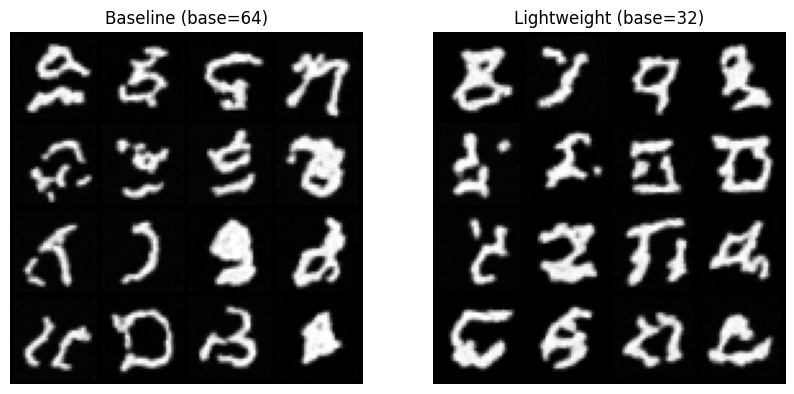

Baseline image: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/baseline_base64.png
Lightweight image: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/lightweight_base32.png


In [19]:
from PIL import Image
import matplotlib.pyplot as plt

base_img_path = base["image_path"]
lite_img_path = lite["image_path"]

assert os.path.exists(base_img_path), f"Missing image: {base_img_path}"
assert os.path.exists(lite_img_path), f"Missing image: {lite_img_path}"

base_img = Image.open(base_img_path)
lite_img = Image.open(lite_img_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(base_img)
plt.axis("off")
plt.title(f"Baseline (base={int(base['base_channels'])})")

plt.subplot(1,2,2)
plt.imshow(lite_img)
plt.axis("off")
plt.title(f"Lightweight (base={int(lite['base_channels'])})")

plt.show()

print("Baseline image:", base_img_path)
print("Lightweight image:", lite_img_path)

In [20]:
csv_path = os.path.join(RUN_DIR, "comparison_report.csv")
report.to_csv(csv_path, index=False)
print("✅ Saved CSV report to:", csv_path)

✅ Saved CSV report to: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/comparison_report.csv


The baseline achieves slightly better visual quality, but the lightweight model provides a strong efficiency–quality trade-off, which aligns with the objective of designing computationally efficient diffusion models

,name,base_channels,epochs,params_M,train_time_sec,sample_time_sec,image_path
0,lightweight,32,3,0.293121,71.097250,1.062893,/content/drive/MyDrive/CSE499B_Lightweight_Dif...
1,baseline,64,3,1.011969,102.258646,1.046093,/content/drive/MyDrive/CSE499B_Lightweight_Dif...


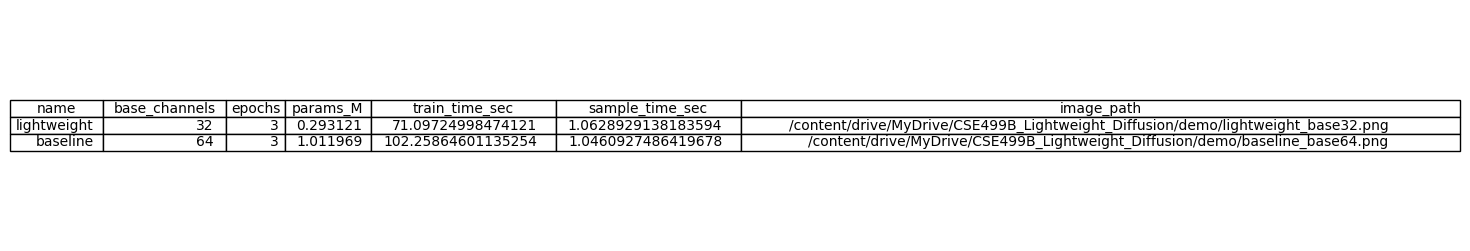

✅ CSV report image saved to: /content/drive/MyDrive/CSE499B_Lightweight_Diffusion/demo/comparison_report.png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load CSV
csv_path = os.path.join(RUN_DIR, "comparison_report.csv")
df = pd.read_csv(csv_path)

display(df)  # show normal table first

# Create image from dataframe
fig, ax = plt.subplots(figsize=(12, 2 + len(df)*0.5))
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(df.columns))))

img_path = os.path.join(RUN_DIR, "comparison_report.png")
plt.savefig(img_path, bbox_inches='tight', dpi=300)
plt.show()

print("✅ CSV report image saved to:", img_path)